In [5]:
#loading required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


In [6]:
#load dataset
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
maternal_health_risk = fetch_ucirepo(id=863) 

#dataset
mat_risk = maternal_health_risk.data.original

print(mat_risk.head())

   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


**Variable descriptions:**
- Age: Age in years when a woman was pregnant.
- SystolicBP: Upper value of Blood Pressure in mmHg.
- DiastolicBP: Lower value of Blood Pressure in mmHg.
- BS: Blood glucose levels in terms of molar concentration.
- BodyTemp: Body temperature in Fahrenheit.
- HeartRate: A normal resting heart rate
- RiskLevel: Target variable - Predicted Risk Intensity Level during pregnancy considering the previous attributes.

In [7]:
#Check dataset info
mat_risk.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [8]:
mat_risk.info()
mat_risk.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

There are no missing values in this dataset.

In [9]:
#Data Cleaning and Preprocessing
#Remove trailing spaces
mat_risk.columns.str.strip()

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='object')

#### Checking target variable

In [10]:
#checking target variable
mat_risk["RiskLevel"].unique()

array(['high risk', 'low risk', 'mid risk'], dtype=object)

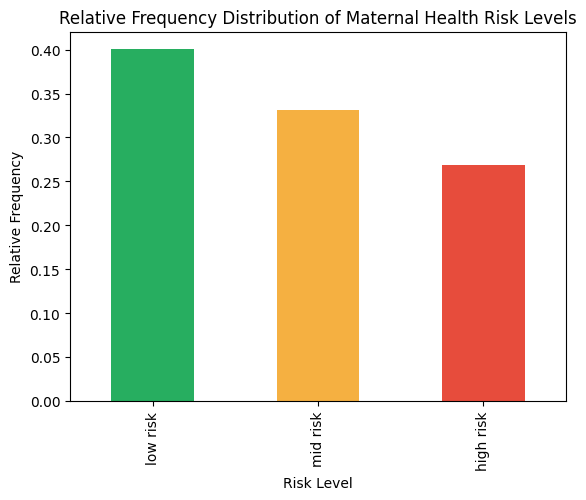

In [11]:
#getting relative frequencies of each level in target variable
#chart
mat_risk["RiskLevel"].value_counts(normalize=True).plot(kind="bar",color=["#27ae60","#f5b041","#e74c3c"])
plt.title('Relative Frequency Distribution of Maternal Health Risk Levels')
plt.ylabel('Relative Frequency')
plt.xlabel('Risk Level')
plt.show()


This frequency distribution is acceptable for a classification task, since all three classes have a reasonable share of data.

Evaluating relationships between variables

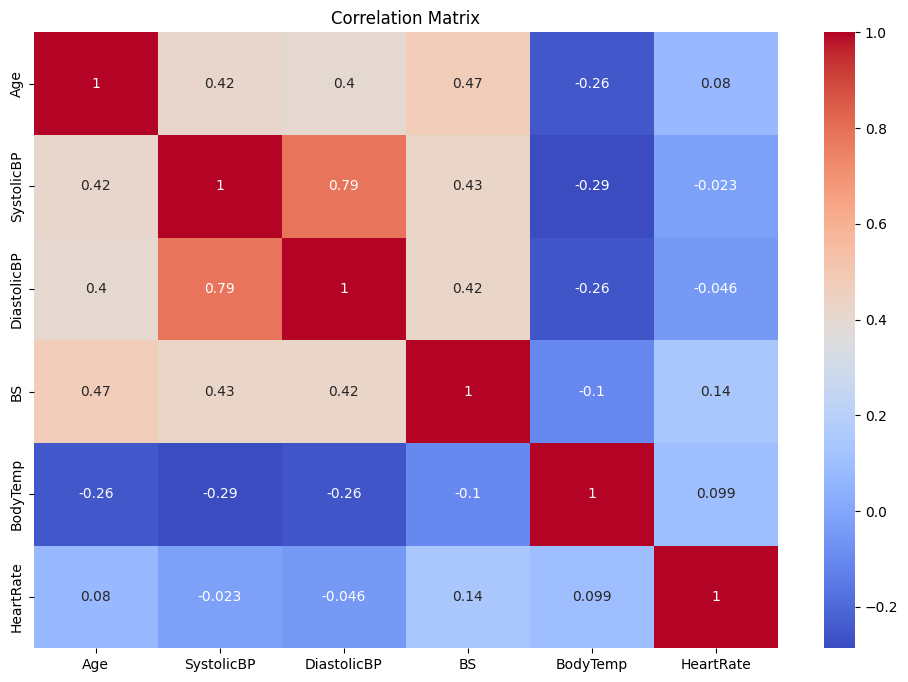

In [12]:
#Correlation between features
plt.figure(figsize=(12,8))
sns.heatmap(mat_risk.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

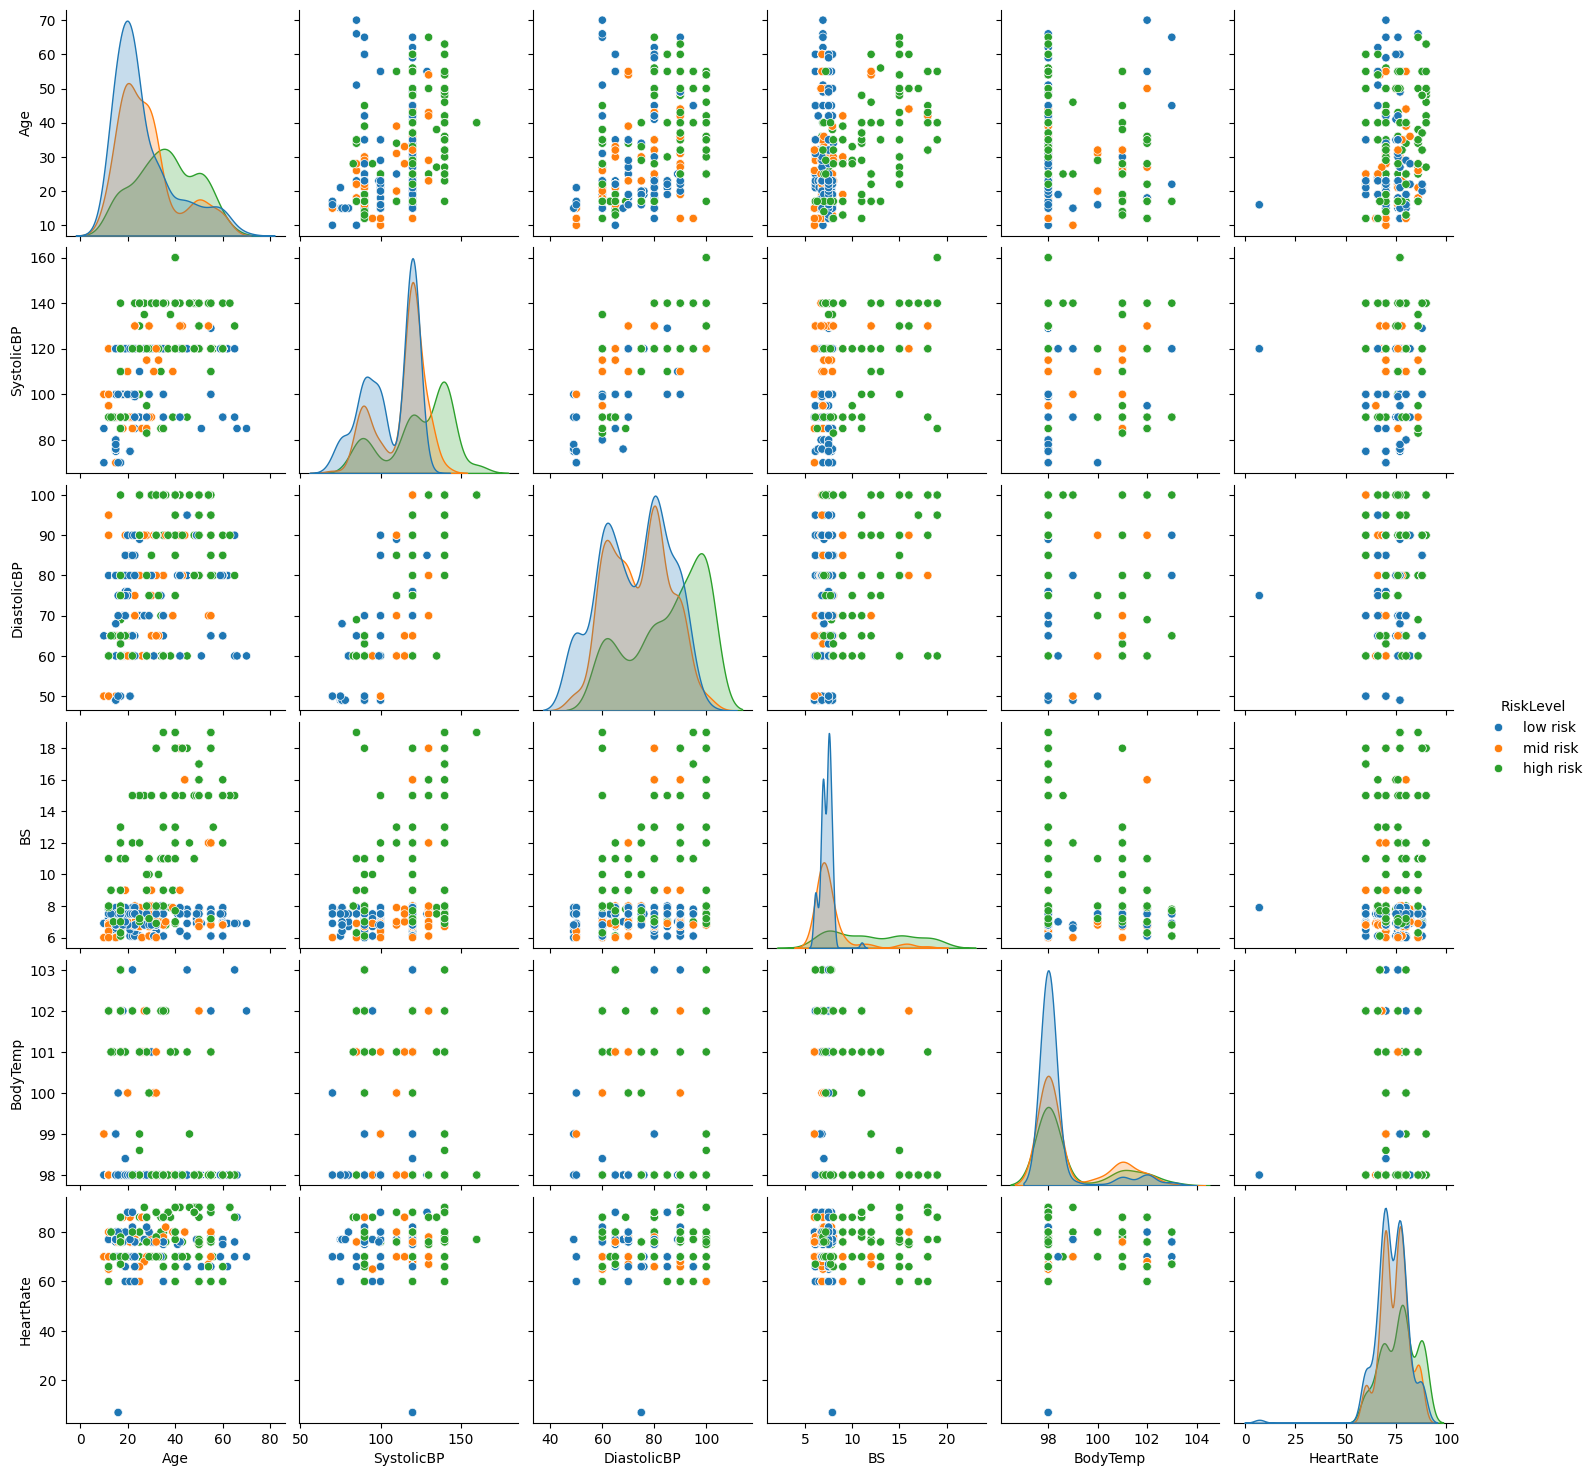

In [13]:
sns.pairplot(mat_risk,hue="RiskLevel",hue_order=["low risk","mid risk","high risk"])

There is some correlation between Systolic BP and Diastolic BP (naturally), so we introduce a new feature - Pulse Pressure. 

<Axes: >

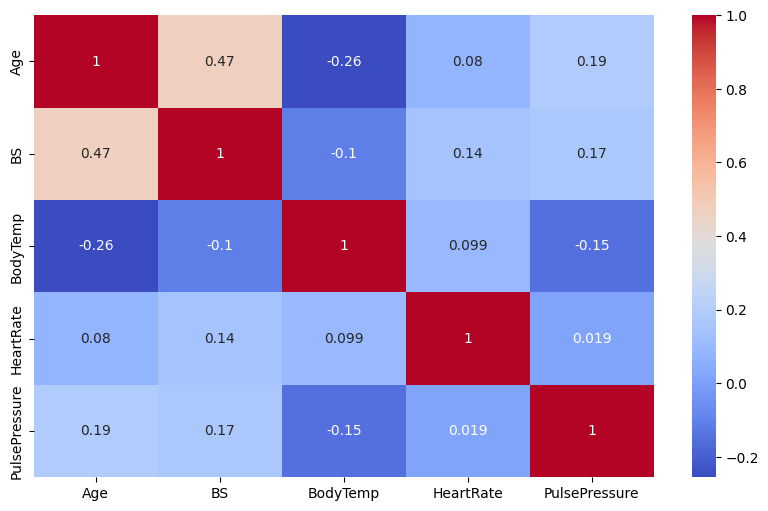

In [14]:
#creating pulse pressure'
mat_risk["PulsePressure"] = mat_risk["SystolicBP"]-mat_risk["DiastolicBP"]
mat_risk_new = mat_risk.drop(["SystolicBP","DiastolicBP"],axis=1)

plt.figure(figsize=(10,6))
sns.heatmap(mat_risk_new.corr(numeric_only=True),annot=True,cmap="coolwarm")

We see that there is no significant linear correlation between features.

Encoding the target variable for model fitting

In [16]:
#Encode target variable
le = LabelEncoder()

mat_risk_new["RiskLevel_enc"] = le.fit_transform(mat_risk["RiskLevel"])

#check mapping
mat_risk_new[["RiskLevel","RiskLevel_enc"]].head(10)

,RiskLevel,RiskLevel_enc
0,high risk,0
1,high risk,0
2,high risk,0
3,high risk,0
4,low risk,1
5,high risk,0
6,mid risk,2
7,high risk,0
8,mid risk,2
9,high risk,0


Encoding: high risk = 0, low risk = 1, mid risk = 2

In [17]:
#We can drop the original RiskLevel column and only keep RiskLevel_enc
mat_risk_new.drop("RiskLevel",axis=1,inplace=True)

In [19]:
#feature-target split
X = mat_risk_new.drop("RiskLevel_enc",axis=1)
y= mat_risk_new["RiskLevel_enc"]


#train-test split
X_train,X_test, y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)


In [20]:
#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Model Fitting and Evaluation

Logistic Regression accuracy: 0.6206896551724138
Classification Report: 
              precision    recall  f1-score   support

           0       0.86      0.67      0.76        55
           1       0.59      0.83      0.69        81
           2       0.48      0.33      0.39        67

    accuracy                           0.62       203
   macro avg       0.64      0.61      0.61       203
weighted avg       0.63      0.62      0.61       203



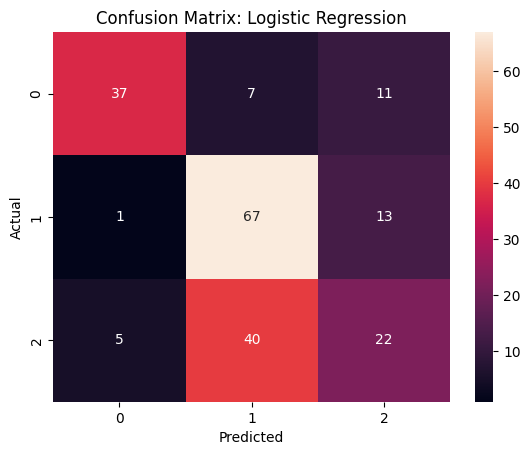

KNN accuracy: 0.6847290640394089
Classification Report: 
              precision    recall  f1-score   support

           0       0.76      0.69      0.72        55
           1       0.66      0.74      0.70        81
           2       0.66      0.61      0.64        67

    accuracy                           0.68       203
   macro avg       0.69      0.68      0.69       203
weighted avg       0.69      0.68      0.68       203



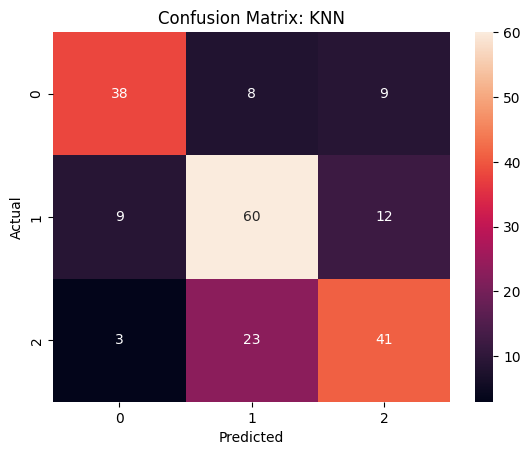

Random Forest accuracy: 0.8571428571428571
Classification Report: 
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        55
           1       0.88      0.80      0.84        81
           2       0.79      0.85      0.82        67

    accuracy                           0.86       203
   macro avg       0.86      0.87      0.86       203
weighted avg       0.86      0.86      0.86       203



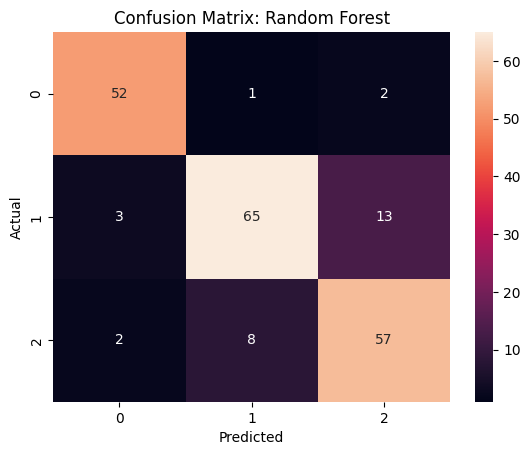

Gradient Boosting accuracy: 0.7881773399014779
Classification Report: 
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        55
           1       0.78      0.81      0.80        81
           2       0.73      0.70      0.72        67

    accuracy                           0.79       203
   macro avg       0.79      0.79      0.79       203
weighted avg       0.79      0.79      0.79       203



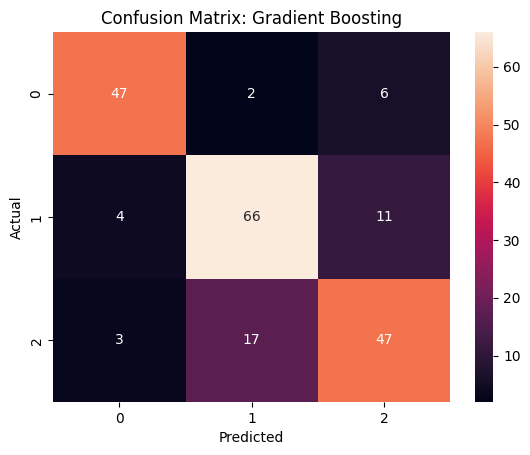

In [21]:
#creating a pipeline
models = {"Logistic Regression":LogisticRegression(),"KNN":KNeighborsClassifier(),"Random Forest":RandomForestClassifier(),"Gradient Boosting":GradientBoostingClassifier()}

for name,model in models.items():
    model.fit(X_train_scaled,y_train)
    test_score = model.score(X_test_scaled,y_test)
    y_pred = model.predict(X_test_scaled)
    accuracy = model.score(X_test_scaled,y_test)
    rep = classification_report(y_test,y_pred)
    
    print("{} accuracy: {}".format(name,accuracy,rep))
    print("Classification Report: \n{}".format(rep))

    sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="d")
    plt.title("Confusion Matrix: {}".format(name))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


We can see that Random Forest has the highest accuracy. 

Finalizing Random Forest Model

C:\Users\janha\AppData\Local\Temp\ipykernel_30940\2657840425.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')


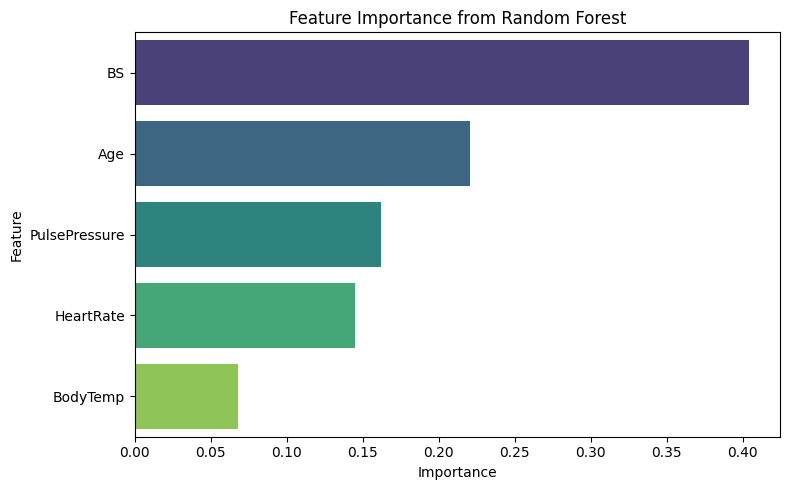

In [22]:
#feature importance plot
rf = RandomForestClassifier()
rf.fit(X_train_scaled,y_train)

#create a dataframe for visualization
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({"Feature":features,"Importance":importances})
feat_imp = feat_imp.sort_values(by="Importance",ascending=False)

#plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

From the plot, we can say that Blood Sugar was the most predictive feature.